<a href="https://colab.research.google.com/github/mary1363/Knn-Regression-housing-price-prediction/blob/main/Count_People_CV_Time_Series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Install packages

In [ ]:
# Computer Vision & Detection
!pip install opencv-python       # Reading & processing images/frames
!pip install ultralytics         # YOLOv8 for person detection

# Tracking
!pip install deep-sort-realtime  # Person tracking & unique ID assignment

# Data Analysis & Time Series
!pip install pandas              # Data tables & DataFrame management
!pip install numpy               # Numerical computations & arrays
!pip install matplotlib          # Plotting images & charts
!pip install seaborn             # Advanced statistical plots

# Time Serires & Forcasting
!pip install statsmodels         # Statistical models (e.g., ARIMA)
!pip install prophet             # Forcasting people counts over time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 62.0 MB/s eta 0:00:00


### Import basic libraries

In [3]:
import os
import cv2                      # Image/frame reading and processing
import numpy as np              # Arrays & numerical operations
import pandas as pd             # DataFrames & table operations
import matplotlib.pyplot as plt # plotting
import seaborn as sns           # Statistical plots
import scipy.io as sio          # Reading MATLAB

In [4]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Verify Videos & Ground Truth(RGB + Depth)

In [ ]:
# Base paths
video_base = '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS'
gt_path = '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/GROUND TRUTH'

# Recursively find all .mkv videos
all_videos = []
for root, dirs, files in os.walk(video_base):
    for f in files:
        if f.endswith('.mkv'):
            all_videos.append(os.path.join(root, f))

# Separate RGB and Depth videos
rgb_videos = [v for v in all_videos if '/RGB/' in v.replace("\\","/")]
depth_videos = [v for v in all_videos if '/DEPTH/' in v.replace("\\","/")]

print("Total videos found:", len(all_videos))
print("RGB videos:", len(rgb_videos))
print("Depth videos:", len(depth_videos))
print("Sample RGB videos:", rgb_videos[:3])
print("Sample Depth videos:", depth_videos[:3])

# Verify each video has a matching ground truth
gt_files = [f for f in os.listdir(gt_path) if f.endswith('.xgtf')]
missing_gt = []
for video_path in all_videos:
    video_name = os.path.basename(video_path)
    gt_name = video_name.replace('.mkv', '.xgtf')
    if gt_name not in gt_files:
        missing_gt.append(video_name)

if missing_gt:
    print("Videos missing ground truth:", missing_gt)
else:
    print("All videos have corresponding ground truth files.")

Total videos found: 34
RGB videos: 17
Depth videos: 17
Sample RGB videos: ['/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/RGB/C_O_S_4.mkv', '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/RGB/C_O_S_3.mkv', '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/RGB/C_O_S_2.mkv']
Sample Depth videos: ['/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/DEPTH/D_O_S_4.mkv', '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/DEPTH/D_O_S_2.mkv', '/content/drive/MyDrive/CV_project/Dataset People Counting MIVIA/Dataset People Counting MIVIA/DBc/VIDEOS/DEPTH/D_O_S_3.mkv']
All videos have corresponding ground truth files.


**MIVIA People Counting Dataset**

 – Short Summary

 • Includes 34 videos → 17 RGB (color) + 17 Depth (distance map) recorded from an overhead camera (640×480, 30 FPS).

 • Contains indoor/outdoor scenes with single and group crossings.

 • RGB videos: used for main person detection.

 • Depth videos: grayscale distance images, helpful in crowded or low-light situations.

 • Each video has a matching .xgtf Ground Truth file describing:

 • the frame of crossing /
 • the direction (L→R, R→L, T→B, B→T) /
 • the crossing configuration

 • Ground Truth does not include bounding boxes → YOLOv8 must generate them.


### Convert RGB & Depth Videos => Frames

In [ ]:
# Output folders for frames
frame_base = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames'
rgb_frame_folder = os.path.join(frame_base, 'RGB')
depth_frame_folder = os.path.join(frame_base, 'DEPTH')
os.makedirs(rgb_frame_folder, exist_ok=True)
os.makedirs(depth_frame_folder, exist_ok=True)

# Function to convert videos to frames
def video_to_frames(video_list, output_folder):
    for video_path in video_list:
        video_name = os.path.basename(video_path)[:-4]  # remove .mkv
        cap = cv2.VideoCapture(video_path)
        count = 0
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame_name = f"{video_name}_frame_{count:05d}.jpg"
            cv2.imwrite(os.path.join(output_folder, frame_name), frame)
            count += 1
        cap.release()
        print(f"Converted {video_name} → {count} frames in {output_folder}")

# Convert RGB videos
print("Converting RGB videos...")
video_to_frames(rgb_videos, rgb_frame_folder)

# Convert Depth videos
print("Converting Depth videos...")
video_to_frames(depth_videos, depth_frame_folder)

Converting RGB videos...
Converted C_O_S_4 → 4858 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_S_3 → 4451 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_S_2 → 4666 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_S_1 → 4753 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_5 → 4398 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_4 → 4898 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_3 → 5879 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_2 → 4379 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_I_S_5 → 1845 frames in /content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB
Converted C_O_G_1 → 4

- This cell loads all RGB and Depth videos and converts them into image frames.
- Extracted frames will be saved under /frames/RGB and /frames/DEPTH for further processing.
- These frames will later be used for YOLOv8 person detection and bounding-box generation.

### Model Loading with YOLO

In [5]:
# Install Ultralytics YOLOv8
!pip install ultralytics --quiet

from ultralytics import YOLO
import torch

# Load pretrained YOLOv8 model (nano = fastest)
model = YOLO('yolov8n.pt')

print("YOLOv8 loaded successfully!")
print("Torch device:", "CUDA (GPU)" if torch.cuda.is_available() else "CPU")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.9 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 loaded successfully!
Torch device: CPU


- This cell runs YOLOv8 on a sample extracted frame.
- It performs person detection, generates bounding boxes, and draws them on the frame.
- The processed frame is displayed to verify that the detection pipeline works correctly.

### YOLOV8 Inference on Sample Frames

WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.12/dist-packages/ultralytics/assets'.

image 1/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 199.5ms
image 2/2 /usr/local/lib/python3.12/dist-packages/ultralytics/assets/zidane.jpg: 384x640 2 persons, 1 tie, 157.4ms
Speed: 4.0ms preprocess, 178.4ms inference, 2.2ms postprocess per image at shape (1, 3, 384, 640)


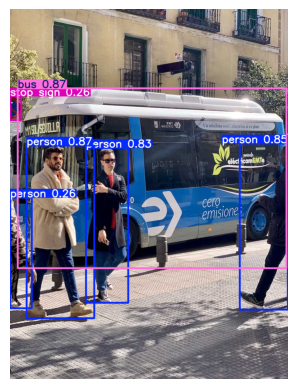

In [13]:
# Run YOLOv8 on a sample frame
sample_frame = '/content/rive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB/C_I_S_3/frame_0000.jpg'

img = cv2.imread(sample_frame)
results = model(img)
annotated = results[0].plot()

plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [9]:
from ultralytics import YOLO
import cv2
import os
import matplotlib.pyplot as plt

# Load YOLOv8 model
model = YOLO('yolov8n.pt')

# Base folder containing RGB frame subfolders
base_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'

# Recursively get all jpg frames from subfolders
sample_frames = []
for root, dirs, files in os.walk(base_frame_folder):
    for f in files:
        if f.endswith('.jpg'):
            sample_frames.append(os.path.join(root, f))

# Pick first 5 frames for testing
sample_frames = sorted(sample_frames)[:5]

# Output folder for annotated images (local Colab)
output_folder = '/content/results/annotated_frames'
os.makedirs(output_folder, exist_ok=True)

for frame_path in sample_frames:
    img = cv2.imread(frame_path)
    results = model(img)
    annotated = results[0].plot()

    # Save locally on Colab, not Google Drive
    save_path = os.path.join(output_folder, os.path.basename(frame_path))
    cv2.imwrite(save_path, annotated)

    # Display inline
    plt.figure(figsize=(6,6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

print(f"YOLOv8 inference completed. Annotated frames saved locally at: {output_folder}")

YOLOv8 inference completed. Annotated frames saved locally at: /content/results/annotated_frames


- This cell runs YOLOv8 detection on a few sample RGB frames.
- It detects persons, draws bounding boxes, saves the annotated frames, and displays them to verify that the detection pipeline works correctly.

In [14]:
import os

base_frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'
all_frames = []

for root, dirs, files in os.walk(base_frame_folder):
    for f in files:
        if f.endswith('.jpg'):
            all_frames.append(os.path.join(root, f))

print("Number of frames found:", len(all_frames))
print("Sample frames:", all_frames[:5])

Number of frames found: 0
Sample frames: []


In [15]:
!ls "/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB"

ls: cannot access '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB': No such file or directory


### Full YOLOV8 Inference & Bounding Box csv

In [ ]:
# Load YOLOv8 model
model = YOLO('yolov8n.pt')

# Paths
frame_folder = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/data/frames/RGB'
output_csv = '/content/drive/MyDrive/CV_project/FlowVisionAI_Project/results/yolo_detections.csv'

# List all frames
all_frames = sorted([f for f in os.listdir(frame_folder) if f.endswith('.jpg')])

# Prepare DataFrame to store bounding boxes
columns = ['frame', 'person_id', 'x1', 'y1', 'x2', 'y2', 'confidence']
df = pd.DataFrame(columns=columns)

# Process each frame
for idx, frame_file in enumerate(all_frames):
    frame_path = os.path.join(frame_folder, frame_file)
    img = cv2.imread(frame_path)

    # Run YOLOv8 inference
    results = model(img)

    # Extract bounding boxes
    for i, box in enumerate(results[0].boxes.xyxy):
        x1, y1, x2, y2 = box.tolist()
        confidence = results[0].boxes.conf[i].item()
        df = pd.concat([df, pd.DataFrame([[frame_file, i, x1, y1, x2, y2, confidence]], columns=columns)], ignore_index=True)

    if idx % 50 == 0:
        print(f"Processed {idx+1}/{len(all_frames)} frames")

# Save CSV
df.to_csv(output_csv, index=False)
print(f"All bounding boxes saved to: {output_csv}")


0: 480x640 (no detections), 472.7ms
Speed: 12.0ms preprocess, 472.7ms inference, 8.2ms postprocess per image at shape (1, 3, 480, 640)
Processed 1/72951 frames

0: 480x640 (no detections), 606.8ms
Speed: 9.6ms preprocess, 606.8ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 561.9ms
Speed: 7.8ms preprocess, 561.9ms inference, 3.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 330.9ms
Speed: 9.7ms preprocess, 330.9ms inference, 3.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 422.6ms
Speed: 11.1ms preprocess, 422.6ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 325.4ms
Speed: 5.5ms preprocess, 325.4ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 276.0ms
Speed: 7.3ms preprocess, 276.0ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections),

/tmp/ipython-input-3441866354.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame([[frame_file, i, x1, y1, x2, y2, confidence]], columns=columns)], ignore_index=True)


Streaming output truncated to the last 5000 lines.
Speed: 7.4ms preprocess, 265.7ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 287.6ms
Speed: 4.7ms preprocess, 287.6ms inference, 1.4ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 308.2ms
Speed: 10.8ms preprocess, 308.2ms inference, 2.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 dog, 251.9ms
Speed: 4.7ms preprocess, 251.9ms inference, 2.0ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 (no detections), 300.6ms
Speed: 3.3ms preprocess, 300.6ms inference, 1.5ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 299.4ms
Speed: 4.4ms preprocess, 299.4ms inference, 5.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 369.1ms
Speed: 5.0ms preprocess, 369.1ms inference, 2.3ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 2 dogs, 554.1ms
Speed: 12.3ms preprocess, 554.1ms inference

- This cell runs YOLOv8 detection on all RGB frames.
- It extracts bounding boxes for all detected persons in each frame,
- stores the results in a DataFrame, and saves them to a CSV file.
- This CSV will be used later for tracking and counting.